<a href="https://colab.research.google.com/github/aggarwal-navya/DeepLearning/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [49]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [50]:
X= df.drop("PE", axis=1)
y= df["PE"]

In [51]:
y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

In [53]:
X_test

,AT,V,AP,RH
2513,29.70,57.35,1005.63,57.35
9411,25.71,71.64,1008.85,77.31
8745,17.83,44.92,1025.04,70.58
9085,9.46,41.40,1026.78,87.58
4950,29.90,64.79,1016.90,48.24
...,...,...,...,...
7204,20.46,51.43,1010.06,83.79
1599,29.70,67.17,1007.31,66.56
5697,14.64,39.58,1011.46,71.90
350,29.47,71.32,1008.07,67.00


In [54]:
df.shape

(9568, 5)

In [55]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [56]:
import torch
import torch.nn as nn
X_train_tensor=torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor= torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor= torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [57]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset= TensorDataset(X_train_tensor, y_train_tensor)
test_dataset= TensorDataset(X_test_tensor, y_test_tensor)

In [58]:
train_loader= DataLoader(train_dataset, batch_size=32, shuffle= True)
test_loader= DataLoader(test_dataset, batch_size=32)

#DeepLearn


In [59]:
class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()

    self.model = nn.Sequential(
        # 1st hidden layer
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),

        #2nd input layer
        nn.Linear(6,6),
        nn.ReLU(),

        #output layer
        nn.Linear(6,1),
  )

  def forward(self, x):
    return self.model(x)

In [60]:
import torch.optim as optim

model= ANN()
criterion= nn.MSELoss()
optimizer= optim.Adam(model.parameters())

In [61]:
# train
train_losses=[]
val_losses=[]

best_val_loss= float("inf")

epochs= 100
for epoch in range(epochs):
  model.train()
  running_loss= 0.0 #training loss of 1 epoch
  for xb, yb in train_loader:
    #xb= feature of one batch and yb = labels of 1 batch
    optimizer.zero_grad()

    outputs= model(xb) #predicted outputs of this batch
    loss= criterion(outputs,yb)
    loss.backward()# backprop..compute gradient
    optimizer.step() #update paramerters
    running_loss += loss.item()
  epoch_train_loss= running_loss / len(train_loader)
  train_losses.append(epoch_train_loss)


  # validation
  model.eval()
  running_val_loss= 0.0

  with torch.no_grad(): # no gradients compute
    for xb, yb in test_loader:
      outputs= model(xb)
      loss= criterion(outputs, yb)
      running_val_loss += loss

  epoch_val_loss= running_val_loss / len(test_loader)
  val_losses.append(epoch_val_loss)

  print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_train_loss}, Val Loss: {epoch_val_loss}")

  if epoch_val_loss < best_val_loss:
    best_val_loss= epoch_val_loss
    torch.save(model.state_dict(), "best_model.pt") # .pt or .pth
    print("Model saved")

Epoch 1/100, Train Loss: 205768.98515625, Val Loss: 203461.640625
Model saved
Epoch 2/100, Train Loss: 196019.16028645833, Val Loss: 183632.265625
Model saved
Epoch 3/100, Train Loss: 159142.36780598958, Val Loss: 127903.4921875
Model saved
Epoch 4/100, Train Loss: 94020.74768880209, Val Loss: 63511.30078125
Model saved
Epoch 5/100, Train Loss: 44677.288728841144, Val Loss: 30689.1328125
Model saved
Epoch 6/100, Train Loss: 23848.647501627605, Val Loss: 18586.27734375
Model saved
Epoch 7/100, Train Loss: 16354.70005086263, Val Loss: 13945.8740234375
Model saved
Epoch 8/100, Train Loss: 12557.290342203776, Val Loss: 10790.439453125
Model saved
Epoch 9/100, Train Loss: 9592.728961181641, Val Loss: 8117.7724609375
Model saved
Epoch 10/100, Train Loss: 7095.185344441732, Val Loss: 5884.095703125
Model saved
Epoch 11/100, Train Loss: 5069.696829223632, Val Loss: 4118.720703125
Model saved
Epoch 12/100, Train Loss: 3494.5307754516602, Val Loss: 2784.62646484375
Model saved
Epoch 13/100, Trai

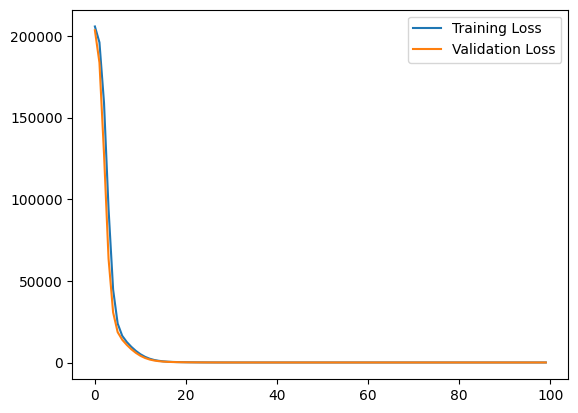

In [62]:
import matplotlib.pyplot as plt
loss_df= pd.DataFrame({"train_loss": train_losses, "val_loss": val_losses})
plt.plot(loss_df["train_loss"], label= "Training Loss")
plt.plot(loss_df["val_loss"], label= "Validation Loss")

plt.legend()

In [63]:
# loading best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [64]:
# evaluation
model.eval()
with torch.no_grad():
  train_preds= model(X_train_tensor)
  test_preds= model(X_test_tensor)

  train_mse_loss= criterion(train_preds, y_train_tensor)
  test_mse_loss= criterion(test_preds, y_test_tensor)

  print(f"Train MSE Loss: {train_mse_loss.item()}")
  print(f"Test MSE Loss: {test_mse_loss.item()}")

Train MSE Loss: 20.23536491394043
Test MSE Loss: 18.589696884155273


In [65]:
from sklearn.metrics import r2_score
print("r2 score", r2_score(y_test, test_preds))


r2 score 0.9350338031881469


In [66]:
predicted_df= pd.DataFrame(test_preds.numpy(), columns= ["Predicted Value"])
actual_df= pd.DataFrame(y_test.values, columns=["Actual Value"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Value,Actual Value
0,434.781891,433.27
1,436.797516,438.16
2,461.802155,458.42
3,477.027344,480.82
4,435.301239,441.41
...,...,...
1909,451.275299,456.70
1910,431.306488,438.04
1911,467.561890,467.80
1912,430.799530,437.14
